In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
students = pd.read_csv(
    "C:\\Users\\lavia\\Downloads\\Student Awareness Survey (Responses) - Form Responses 1.csv"
)
students.head()

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


In [40]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column                                                                                      Non-Null Count  Dtype  
---  ------                                                                                      --------------  -----  
 0   Timestamp                                                                                   50 non-null     object 
 1   Registration Number                                                                         50 non-null     int64  
 2   Email                                                                                       50 non-null     object 
 3   Job role that you are interested in                                                         50 non-null     object 
 4   What is the minimum salary of students placed through campus (In LPA..respond as a number)  50 non-null     object 
 5   What is the maximum salary of students placed

In [41]:
students.shape

(50, 15)

In [42]:
students.describe()

,Registration Number,Rate your contribution towards extra curricular activities,Rate your technical competencies,Your GPA of last semester
count,5.000000e+01,49.000000,49.000000,50.000000
mean,2.547232e+06,3.489796,3.530612,3.497000
std,1.792671e+01,1.209725,0.738863,0.690865
min,2.547201e+06,1.000000,2.000000,2.740000
25%,2.547217e+06,3.000000,3.000000,3.305000
50%,2.547232e+06,4.000000,3.000000,3.400000
75%,2.547246e+06,4.000000,4.000000,3.600000
max,2.547262e+06,5.000000,5.000000,8.000000


In [43]:
print(students.isnull().sum())

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your package expectations (LPA)

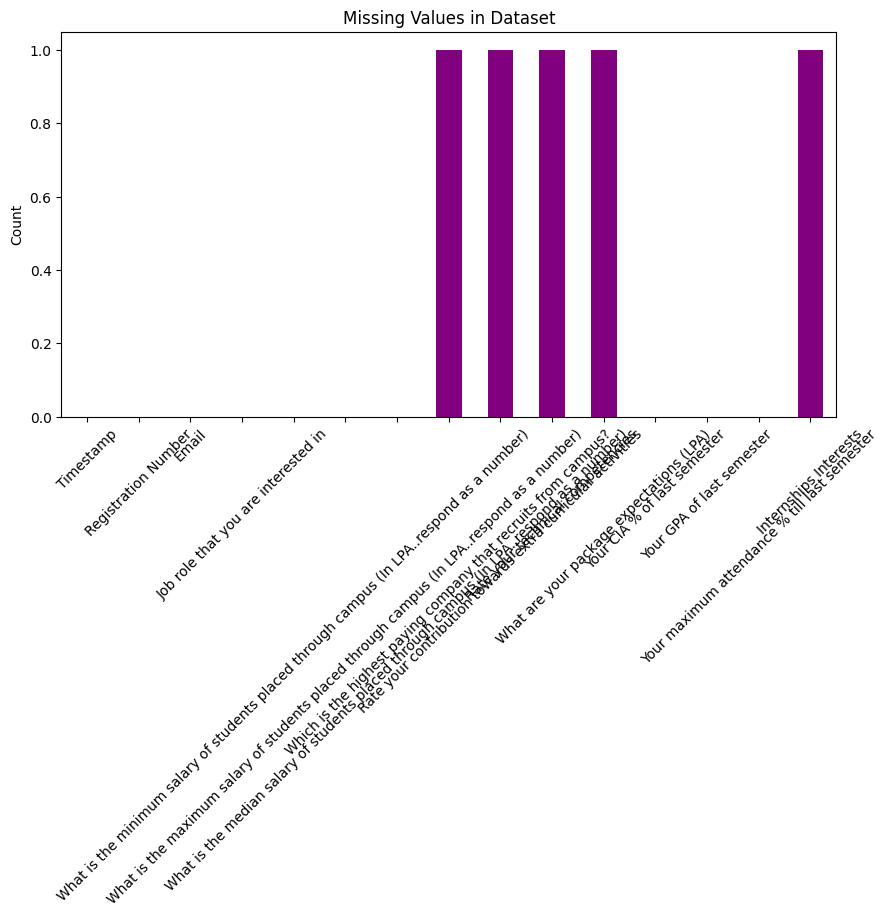

In [44]:
missing = students.isnull().sum()

plt.figure(figsize=(10,5))

missing.plot(
    kind='bar',
    color='purple'
)

plt.title(
    "Missing Values in Dataset"
)

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [45]:
missing_percent = (
    students.isnull().sum()
    / len(students)
) * 100
print(missing_percent)

Timestamp                                                                                     0.0
Registration Number                                                                           0.0
Email                                                                                         0.0
Job role that you are interested in                                                           0.0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0.0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0.0
What is the median salary of students placed through campus (In LPA..respond as a number)     0.0
Which is the highest paying company that recruits from campus?                                2.0
Rate your contribution towards extra curricular activities                                    2.0
Rate your technical competencies                                                              2.0
What are your packag

In [46]:
num_cols = [
'Rate your contribution towards extra curricular activities',
'Rate your technical competencies'
]

for col in num_cols:

    students[col] = students[col].fillna(
        students[col].median()
    )
    

In [47]:
students.isnull().sum()

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package expectations (LPA)

In [48]:
students[
[
'Your CIA % of last semester',
'Your GPA of last semester',
'Your maximum attendance % till last semester'
]
].dtypes

Your CIA % of last semester                      object
Your GPA of last semester                       float64
Your maximum attendance % till last semester     object
dtype: object

In [49]:
num_cols = [
'Your CIA % of last semester',
'Your maximum attendance % till last semester'
]

for col in num_cols:

    students[col] = students[col].str.replace('%','')

    students[col] = pd.to_numeric(
        students[col]
    )



In [50]:
students[
[
'Your CIA % of last semester',
'Your GPA of last semester',
'Your maximum attendance % till last semester'
]
].dtypes

Your CIA % of last semester                     float64
Your GPA of last semester                       float64
Your maximum attendance % till last semester    float64
dtype: object

- CIA and Attendance were stored as text because of the % symbol.
- The % symbol was removed and the values were converted into numerical format.
- Numerical values are required because regression algorithms perform mathematical calculations on numbers only.


In [51]:
students.duplicated().sum()

np.int64(0)

In [52]:
students[
[
'Your CIA % of last semester',
'Your GPA of last semester',
'Your maximum attendance % till last semester'
]
].describe()

,Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester
count,50.000000,50.000000,50.000000
mean,71.508600,3.497000,93.824800
std,11.247756,0.690865,3.852926
min,7.000000,2.740000,85.000000
25%,69.195000,3.305000,92.000000
50%,71.445000,3.400000,95.000000
75%,76.750000,3.600000,96.000000
max,91.000000,8.000000,100.000000


## Selection of Independent and Dependent Variables

The objective of this lab is to study whether GPA can be predicted using CIA Percentage and Attendance Percentage. Therefore, two regression experiments are performed.

### Experiment 1

- **Independent Variable (X):** Your CIA % of last semester
- **Dependent Variable (Y):** Your GPA of last semester

**Reason:** CIA Percentage is used as the predictor variable, while GPA is the outcome variable that needs to be predicted.

### Experiment 2

- **Independent Variable (X):** Your maximum attendance % till last semester
- **Dependent Variable (Y):** Your GPA of last semester

**Reason:** Attendance Percentage is considered as the predictor variable to analyze whether attendance influences the student's GPA.